# Multi-Application EPR From Experiment Folders

This notebook combines:
- robust run-level loading from experiment folders (like otel_release_vs_energy_per_request.ipynb),
- cross-application EPR plotting style inspired by result_figures.ipynb.

It does **not** apply CPU percentile/fixed-util filtering.
All available run-level EPR points are used, then aggregated for means/std/error bars.

In [57]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)

# --- User configuration ---
# Add any number of experiment folders here.
# app: application label used for grouping/stacking
# release: release label shown in legends/axes
# path: experiment root OR release folder containing eoan_/julian_ experiment folders
EXPERIMENT_SPECS = [
    # {
    #     'app': 'otel-demo',
    #     'release': 'v1.12.0',
    #     'path': Path('../final-runs/context-runs/eoan_20260612_150921_702343_otel-demo-1.12.0'),
    # },
    # {
    #     'app': 'otel-demo',
    #     'release': 'v2.0.0',
    #     'path': Path('../final-runs/context-runs/eoan_20260612_194821_154588_otel-demo-2.0.0'),
    # },
    # {
    #     'app': 'otel-demo',
    #     'release': 'v2.2.0',
    #     'path': Path('../final-runs/context-runs/eoan_20260615_102030_823333_otel-demo-2.2.0-2'),
    # },
    # onlineboutique 0.10.5
    # final-runs/experiment-runs-with-attribution/onlineboutique/eoan_20260528_122823_466551_onlineboutique
    # onlineboutique 0.9.0
    # final-runs/experiment-runs-with-attribution/onlineboutique-0.9/eoan_20260610_140850_623587_onlineboutique
    # onlineboutique 0.4.2
    # final-runs/experiment-runs-with-attribution/onlineboutique-0.4.2/eoan_20260610_114027_409533_onlineboutique
    {
        'app': 'onlineboutique',
        'release': 'v0.4.2',
        'path': Path('../final-runs/experiment-runs-with-attribution/onlineboutique-0.4.2/eoan_20260610_114027_409533_onlineboutique'),
    },
    {
        'app': 'onlineboutique',
        'release': 'v0.9.0',
        'path': Path('../final-runs/experiment-runs-with-attribution/onlineboutique-0.9/eoan_20260610_140850_623587_onlineboutique'),
    },
    {
        'app': 'onlineboutique',
        'release': 'v0.10.5',
        'path': Path('../final-runs/experiment-runs-with-attribution/onlineboutique/eoan_20260528_122823_466551_onlineboutique'),
    },
    # train ticket 1.0.0
    # final-runs/experiment-runs-with-attribution/trainticket/eoan_20260618_184034_697565_train-ticket
    # train ticket 0.2.0
    # final-runs/experiment-runs-with-attribution/trainticket-0.0.4/eoan_20260628_184006_790500_train-ticket
    # train ticket 0.0.4
    # final-runs/experiment-runs-with-attribution/trainticket-0.2.0/eoan_20260620_135853_725501_train-ticket
    {
        'app': 'trainticket',
        'release': 'v0.0.4',
        'path': Path('../final-runs/experiment-runs-with-attribution/trainticket-0.0.4/eoan_20260628_184006_790500_train-ticket'),
    },
    {
        'app': 'trainticket',
        'release': 'v0.2.0',
        'path': Path('../final-runs/experiment-runs-with-attribution/trainticket-0.2.0/eoan_20260620_135853_725501_train-ticket'),
    },
    {
        'app': 'trainticket',
        'release': 'v1.0.0',
        'path': Path('../final-runs/experiment-runs-with-attribution/trainticket/eoan_20260618_184034_697565_train-ticket'),
    },

    # Example additional app entries:
    # {
    #     'app': 'onlineboutique',
    #     'release': 'v0.10.0',
    #     'path': Path('../final-runs/context-runs/<folder>'),
    # },
]

WORKLOAD_ORDER = ['low', 'medium', 'high']
WORKLOAD_FILTER = ['low', 'medium', 'high']
ENV_FILTER = ['workstation']

# Diagnostic only (not used for dropping rows in current pipeline).
MAX_ERROR_RATE = 1.000

# Optional explicit run exclusions (iteration token only or workload/iteration token)
EXCLUDED_ITERATIONS = []

# Hard data-source filter toggles
DROP_NEGATIVE_METER_EPR = True
DROP_ZERO_REQUEST_COUNT = True

# Which workload to use in the stacked multi-application release comparison
STACKED_WORKLOAD = 'medium'

# Optional custom plotting order
APP_ORDER = []
RELEASE_ORDER = []

# Figure export
SAVE_FIGURES = True
FIGURES_DIR = Path('figures')

for spec in EXPERIMENT_SPECS:
    if not Path(spec['path']).exists():
        raise FileNotFoundError(f"Missing path in EXPERIMENT_SPECS: {spec['path']}")

print('Configured specs:', len(EXPERIMENT_SPECS))
print('Workloads:', WORKLOAD_FILTER)
print('Environment filter:', ENV_FILTER)
print(f'Diagnostic only: error_rate <= {float(MAX_ERROR_RATE):.4f} (not applied as row-drop filter)')
print('Drop negative meter EPR:', bool(DROP_NEGATIVE_METER_EPR))
print('Drop zero request_count:', bool(DROP_ZERO_REQUEST_COUNT))

Configured specs: 6
Workloads: ['low', 'medium', 'high']
Environment filter: ['workstation']
Diagnostic only: error_rate <= 1.0000 (not applied as row-drop filter)
Drop negative meter EPR: True
Drop zero request_count: True


In [58]:
def extract_json_object_after_marker(text: str, marker: str) -> dict:
    marker_idx = text.find(marker)
    if marker_idx < 0:
        raise ValueError(f"Marker not found: {marker}")

    start = text.find("{", marker_idx)
    if start < 0:
        raise ValueError("Could not find JSON object start after marker")

    depth = 0
    in_string = False
    escaped = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escaped:
                escaped = False
            elif ch == "\\":
                escaped = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
            continue

        if ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return json.loads(text[start : i + 1])

    raise ValueError("Could not find end of JSON object")

def environment_from_folder(name: str) -> str | None:
    if name.startswith("eoan_"):
        return "workstation"
    if name.startswith("julian_"):
        return "ec2"
    return None

def extract_iteration_name(run_name: str) -> str | None:
    s = pd.Series([str(run_name)])
    it = s.str.extract(r"(iteration_[0-9_]+)", expand=False).iloc[0]
    return None if pd.isna(it) else str(it)

def normalize_iteration_token(token: str) -> str:
    s = str(token).strip().strip("/")
    if not s:
        return ""
    if "/" in s:
        s = s.split("/")[-1]
    return s

def choose_epr_j(run: dict) -> float:
    meter = pd.to_numeric(run.get("meter_energy_per_request_joules"), errors="coerce")
    model = pd.to_numeric(run.get("energy_per_request"), errors="coerce")
    if pd.notna(meter):
        return float(meter)
    if pd.notna(model):
        return float(model)
    return float("nan")

def iter_experiment_dirs(root: Path):
    if (root / "runs_comparison.html").exists():
        env = environment_from_folder(root.name)
        if env is not None:
            return [(root, env)]

    out = []
    for d in sorted(root.iterdir()):
        if not d.is_dir():
            continue
        env = environment_from_folder(d.name)
        if env is None:
            continue
        if (d / "runs_comparison.html").exists():
            out.append((d, env))
    return out

def save_figure(fig, stem: str) -> None:
    if not bool(globals().get("SAVE_FIGURES", True)):
        return
    out_dir = Path(globals().get("FIGURES_DIR", Path("figures")))
    out_dir.mkdir(parents=True, exist_ok=True)
    png_path = out_dir / f"{stem}.png"
    pdf_path = out_dir / f"{stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved figure: {png_path} and {pdf_path}")

In [59]:
rows = []

for spec in EXPERIMENT_SPECS:
    app = str(spec['app'])
    release = str(spec['release'])
    root = Path(spec['path'])

    experiments = iter_experiment_dirs(root)
    if not experiments:
        print(f'WARNING: no experiments discovered under {root}')
        continue

    for experiment_dir, env in experiments:
        dashboard_path = experiment_dir / 'runs_comparison.html'
        if not dashboard_path.exists():
            continue

        payload = extract_json_object_after_marker(
            dashboard_path.read_text(encoding='utf-8'),
            'const data = ',
        )

        for run in payload.get('runs', []):
            workload = str(run.get('workload_level', '')).lower()
            if workload not in WORKLOAD_ORDER:
                continue

            run_name = str(run.get('name', ''))
            iteration_name = extract_iteration_name(run_name)

            meter_epr_j = pd.to_numeric(run.get('meter_energy_per_request_joules'), errors='coerce')
            model_epr_j = pd.to_numeric(run.get('energy_per_request'), errors='coerce')
            epr_j = meter_epr_j if pd.notna(meter_epr_j) else model_epr_j

            request_count = pd.to_numeric(run.get('requests'), errors='coerce')
            if pd.isna(request_count):
                request_count = pd.to_numeric(run.get('request_count'), errors='coerce')
            if pd.isna(request_count):
                request_count = pd.to_numeric(run.get('total_requests'), errors='coerce')
            if pd.isna(request_count):
                request_count = pd.to_numeric(run.get('successful_requests'), errors='coerce')
            if pd.isna(request_count):
                request_count = pd.to_numeric(run.get('num_requests'), errors='coerce')
            if pd.isna(request_count):
                request_count = pd.to_numeric(run.get('num_requests_total'), errors='coerce')

            rows.append({
                'app_family': app,
                'release': release,
                'environment': env,
                'workload_level': workload,
                'experiment_folder': experiment_dir.name,
                'run_name': run_name,
                'iteration_name': iteration_name,
                'error_rate': pd.to_numeric(run.get('error_rate'), errors='coerce'),
                'meter_epr_j': meter_epr_j,
                'model_epr_j': model_epr_j,
                'epr_j': pd.to_numeric(epr_j, errors='coerce'),
                'request_count': pd.to_numeric(request_count, errors='coerce'),
            })

runs_df = pd.DataFrame(rows)
if runs_df.empty:
    raise RuntimeError('No run rows parsed. Check EXPERIMENT_SPECS paths and layout.')

runs_df = runs_df[runs_df['environment'].isin([str(x) for x in ENV_FILTER])].copy()
runs_df = runs_df[runs_df['workload_level'].isin([str(x).lower() for x in WORKLOAD_FILTER])].copy()

excluded_tokens = {normalize_iteration_token(x) for x in EXCLUDED_ITERATIONS}
excluded_tokens.discard('')
if excluded_tokens:
    before = len(runs_df)
    runs_df = runs_df[~runs_df['iteration_name'].astype(str).isin(excluded_tokens)].copy()
    print(f'Explicit iteration exclusion dropped {before - len(runs_df)} rows.')

# Hard filter controls (set in the config cell).
meter_negative = pd.to_numeric(runs_df['meter_epr_j'], errors='coerce').lt(0).fillna(False)
request_zero = pd.to_numeric(runs_df['request_count'], errors='coerce').eq(0).fillna(False)

drop_neg_meter = bool(globals().get('DROP_NEGATIVE_METER_EPR', True))
drop_zero_req = bool(globals().get('DROP_ZERO_REQUEST_COUNT', True))

drop_mask = pd.Series(False, index=runs_df.index)
if drop_neg_meter:
    drop_mask = drop_mask | meter_negative
if drop_zero_req:
    drop_mask = drop_mask | request_zero

before_hard = len(runs_df)
runs_df = runs_df[~drop_mask].copy()
print(
    'Applied hard source filter: '
    f'dropped {before_hard - len(runs_df)} rows '
    f'(DROP_NEGATIVE_METER_EPR={drop_neg_meter}, DROP_ZERO_REQUEST_COUNT={drop_zero_req}).'
)

runs_df = runs_df.dropna(subset=['epr_j'])
if runs_df.empty:
    raise RuntimeError('No rows remain after filtering and EPR parsing.')

if RELEASE_ORDER:
    rel_order = list(RELEASE_ORDER)
else:
    rel_order = list(dict.fromkeys(runs_df['release'].astype(str).tolist()))

if APP_ORDER:
    app_order = list(APP_ORDER)
else:
    app_order = sorted(runs_df['app_family'].astype(str).unique().tolist())

runs_df['release'] = pd.Categorical(runs_df['release'], categories=rel_order, ordered=True)
runs_df['app_family'] = pd.Categorical(runs_df['app_family'], categories=app_order, ordered=True)
runs_df['workload_level'] = pd.Categorical(runs_df['workload_level'], categories=WORKLOAD_ORDER, ordered=True)

summary = (
    runs_df.groupby(['app_family', 'environment', 'release', 'workload_level'], observed=True)['epr_j']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .sort_values(['app_family', 'environment', 'release', 'workload_level'])
    .reset_index(drop=True)
)

print('Loaded rows:', len(runs_df))
print('Unique apps:', runs_df['app_family'].astype(str).nunique())
print('Unique releases:', runs_df['release'].astype(str).nunique())
print('Note: error_rate is retained for diagnostics but no longer used as a drop filter.')
display(summary.round(8))

Applied hard source filter: dropped 3 rows (DROP_NEGATIVE_METER_EPR=True, DROP_ZERO_REQUEST_COUNT=True).
Loaded rows: 87
Unique apps: 2
Unique releases: 6
Note: error_rate is retained for diagnostics but no longer used as a drop filter.


,app_family,environment,release,workload_level,mean,std,count
0,onlineboutique,workstation,v0.4.2,low,0.191168,0.056245,5
1,onlineboutique,workstation,v0.4.2,medium,0.071388,0.012972,5
2,onlineboutique,workstation,v0.4.2,high,0.050904,0.005097,5
3,onlineboutique,workstation,v0.9.0,low,0.158230,0.063053,5
4,onlineboutique,workstation,v0.9.0,medium,0.063544,0.006141,5
5,onlineboutique,workstation,v0.9.0,high,0.044993,0.006030,5
6,onlineboutique,workstation,v0.10.5,low,0.001001,0.000559,3
7,onlineboutique,workstation,v0.10.5,medium,0.001873,0.001472,4
8,onlineboutique,workstation,v0.10.5,high,0.002488,0.000266,5
9,trainticket,workstation,v0.0.4,low,0.001507,0.000087,5


Saved figure: figures/figure_epr_workload_multiapp_ws_side_by_side_errorbars_independent_axes.png and figures/figure_epr_workload_multiapp_ws_side_by_side_errorbars_independent_axes.pdf


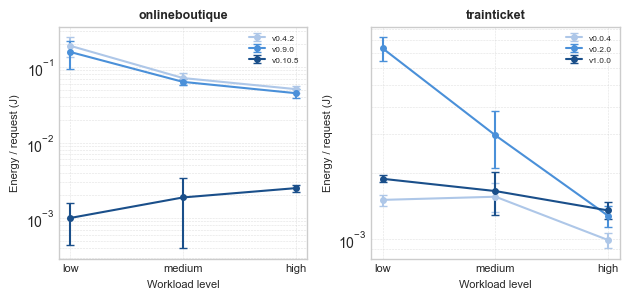

Saved figure: figures/figure_epr_workload_multiapp_ws_vertical_errorbars_independent_axes.png and figures/figure_epr_workload_multiapp_ws_vertical_errorbars_independent_axes.pdf


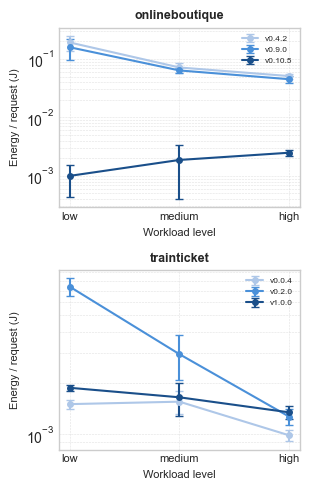

In [63]:
# Figure A: workload trend by release, apps side by side, with error bars
# Style aligned to figure_epr_workload_ws_only (log-y, compact titles, dashed grid).
# Each panel uses its own independent y-axis scale.
plot_df = summary.copy()
apps = [a for a in plot_df['app_family'].astype(str).unique().tolist() if a != 'nan']

if not apps:
    raise RuntimeError('No apps available for Figure A.')

# Use the same base release color progression style as result_figures (oldest -> latest).
base_rel_colors = ['#aec7e8', '#4a90d9', '#1a4f8a']
wl_pos = [0, 1, 2]

def draw_workload_panel(ax, app):
    app_df = plot_df[plot_df['app_family'].astype(str) == app].copy()
    rels = [r for r in app_df['release'].astype(str).unique().tolist() if r != 'nan']

    for rel_idx, rel in enumerate(rels):
        rr = app_df[app_df['release'].astype(str) == rel].copy()
        rr = rr.set_index('workload_level').reindex(WORKLOAD_ORDER).reset_index()

        y = pd.to_numeric(rr['mean'], errors='coerce').to_numpy()
        yerr = pd.to_numeric(rr['std'], errors='coerce').fillna(0.0).to_numpy()

        if rel_idx < len(base_rel_colors):
            color = base_rel_colors[rel_idx]
        else:
            color = plt.get_cmap('tab10')(rel_idx % 10)

        ax.errorbar(
            wl_pos,
            y,
            yerr=yerr,
            marker='o',
            markersize=4,
            linewidth=1.5,
            capsize=3,
            color=color,
            label=rel,
        )

    ax.set_yscale('log')
    ax.set_xticks(wl_pos)
    ax.set_xticklabels(WORKLOAD_ORDER, fontsize=8)
    ax.set_xlabel('Workload level', fontsize=8)
    ax.set_ylabel('Energy / request (J)', fontsize=8)
    ax.set_title(f'{app}', fontsize=9, fontweight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.4, alpha=0.6)
    ax.legend(fontsize=6, loc='best')

# Figure A1: side-by-side panels
fig_w = max(3.2 * len(apps), 6.4)
fig, axes = plt.subplots(1, len(apps), figsize=(fig_w, 3.1), sharey=False)
if len(apps) == 1:
    axes = [axes]

for col, app in enumerate(apps):
    draw_workload_panel(axes[col], app)

fig.tight_layout()
save_figure(fig, 'figure_epr_workload_multiapp_ws_side_by_side_errorbars_independent_axes')
plt.show()

# Figure A2: vertically stacked panels (second image)
# Keep per-panel width equal to the side-by-side panel width for single-column layouts.
panel_w = fig_w / len(apps)
fig_h = max(2.5 * len(apps), 4.0)
fig_v, axes_v = plt.subplots(len(apps), 1, figsize=(panel_w, fig_h), sharey=False)
if len(apps) == 1:
    axes_v = [axes_v]

for row, app in enumerate(apps):
    draw_workload_panel(axes_v[row], app)

fig_v.tight_layout()
save_figure(fig_v, 'figure_epr_workload_multiapp_ws_vertical_errorbars_independent_axes')
plt.show()

Saved figure: figures/figure_epr_stacked_multiapp_medium_no_cpu_filter.png and figures/figure_epr_stacked_multiapp_medium_no_cpu_filter.pdf


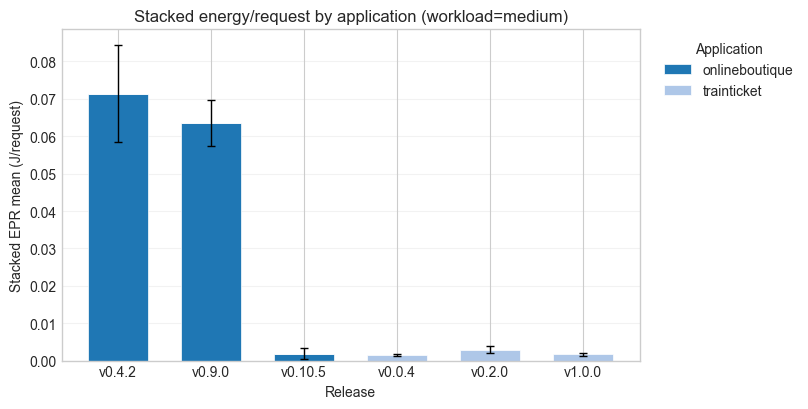

,release,app_family,mean,std,count
0,v0.4.2,onlineboutique,0.071388,0.012972,5
1,v0.9.0,onlineboutique,0.063544,0.006141,5
2,v0.10.5,onlineboutique,0.001873,0.001472,4
3,v0.0.4,trainticket,0.001558,0.000236,5
4,v0.2.0,trainticket,0.002960,0.000863,5
5,v1.0.0,trainticket,0.001652,0.000362,5


In [61]:
# Figure B: stacked EPR across applications by release for one workload (with total error bars)
stack_df = runs_df[runs_df['workload_level'].astype(str) == str(STACKED_WORKLOAD)].copy()
if stack_df.empty:
    raise RuntimeError(f'No rows for STACKED_WORKLOAD={STACKED_WORKLOAD}.')

stack_summary = (
    stack_df.groupby(['release', 'app_family'], observed=True)['epr_j']
    .agg(mean='mean', std='std', count='count')
    .reset_index()
)

release_levels = [r for r in stack_df['release'].cat.categories if pd.notna(r)]
release_levels = [str(r) for r in release_levels if str(r) in stack_summary['release'].astype(str).unique()]
app_levels = [a for a in stack_df['app_family'].cat.categories if pd.notna(a)]
app_levels = [str(a) for a in app_levels if str(a) in stack_summary['app_family'].astype(str).unique()]

if not release_levels or not app_levels:
    raise RuntimeError('Not enough data for stacked chart.')

plot_mat = (
    stack_summary.assign(release=stack_summary['release'].astype(str), app_family=stack_summary['app_family'].astype(str))
    .pivot(index='release', columns='app_family', values='mean')
    .reindex(index=release_levels, columns=app_levels)
    .fillna(0.0)
)
std_mat = (
    stack_summary.assign(release=stack_summary['release'].astype(str), app_family=stack_summary['app_family'].astype(str))
    .pivot(index='release', columns='app_family', values='std')
    .reindex(index=release_levels, columns=app_levels)
    .fillna(0.0)
)

totals = plot_mat.sum(axis=1)
total_err = np.sqrt((std_mat ** 2).sum(axis=1))

fig, ax = plt.subplots(figsize=(8.2, 4.2))
x = np.arange(len(release_levels))
bottom = np.zeros(len(release_levels))

palette = plt.get_cmap('tab20')
for i, app in enumerate(app_levels):
    vals = plot_mat[app].to_numpy()
    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.65,
        label=app,
        color=palette(i % 20),
        edgecolor='white',
        linewidth=0.5,
    )
    bottom += vals

ax.errorbar(
    x,
    totals.to_numpy(),
    yerr=total_err.to_numpy(),
    fmt='none',
    ecolor='black',
    elinewidth=1.0,
    capsize=3,
    zorder=5,
)

ax.set_xticks(x)
ax.set_xticklabels(release_levels, rotation=0)
ax.set_xlabel('Release')
ax.set_ylabel('Stacked EPR mean (J/request)')
ax.set_title(f'Stacked energy/request by application (workload={STACKED_WORKLOAD})')
ax.grid(True, axis='y', alpha=0.25)
ax.legend(title='Application', bbox_to_anchor=(1.02, 1), loc='upper left')

fig.tight_layout()
save_figure(fig, f'figure_epr_stacked_multiapp_{STACKED_WORKLOAD}_no_cpu_filter')
plt.show()

display(stack_summary.sort_values(['release', 'app_family']).round(8))